# 23CSE463 – Quantum Computing
## Worksheet 4: Quantum Data Encoding, Quantum Kernels and Quantum Clustering / QSVM Using Qiskit

**Name:** Agneay B Nair  
**Reg. No:** CH.SC.U4CSE24102  
**Ex. No:** 4

**Aim:** To encode classical data into quantum states using basis, angle and amplitude encoding in Qiskit, to compute a quantum kernel from the overlap of encoded states, and to use it for classification (QSVM) and clustering on a small dataset, with a comparison against a classical method.

### Setup

In [1]:
# Common setup for all programs in this worksheet
%matplotlib inline
import qiskit, numpy as np, matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

print("Qiskit version:", qiskit.__version__)
sim = AerSimulator()
_seed = 2024                                      # seeds incremented per run -> reproducible counts
np.set_printoptions(precision=3, suppress=True, linewidth=110)
plt.rcParams["figure.dpi"] = 100

def show(fig):
    """display a matplotlib figure (circuit diagram / histogram) and close it"""
    display(fig); plt.close(fig)

def run(qc, shots=1024):
    global _seed
    _seed += 1
    return sim.run(transpile(qc, sim), shots=shots, seed_simulator=_seed).result().get_counts()

def amps(sv, tol=1e-9):
    """print the non-zero amplitudes of a statevector with Qiskit labels (qubit 0 rightmost)"""
    n = sv.num_qubits
    for i, a in enumerate(sv.data):
        if abs(a) > tol:
            print(f"  |{i:0{n}b}> : {a.real:+.3f}{a.imag:+.3f}j   P = {abs(a)**2:.3f}")


from sklearn.datasets import load_iris, make_blobs
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import accuracy_score, adjusted_rand_score

def basis_encode(bits):
    qc = QuantumCircuit(len(bits))
    for i, b in enumerate(reversed(bits)):      # rightmost bit -> qubit 0
        if b == "1":
            qc.x(i)
    return qc

def angle_encode(x):
    """x: features already scaled to [0,1]; one qubit per feature, theta = pi*x"""
    qc = QuantumCircuit(len(x))
    for i, xi in enumerate(x):
        qc.ry(np.pi * xi, i)
    return qc

def state(x):
    return Statevector(angle_encode(x))

def kernel(x1, x2):
    return abs(state(x1).inner(state(x2))) ** 2

def kernel_matrix(A, B):
    SA = [state(a) for a in A]; SB = [state(b) for b in B]
    return np.array([[abs(sa.inner(sb)) ** 2 for sb in SB] for sa in SA])


Qiskit version: 2.5.2


### Program 1
Encode the bit string 1011 using basis encoding. Verify that the printed state is 1011. Repeat with a four-bit string of your own choice.

Bits 1011 -> state probabilities: {'1011': 1.0}   matches: True


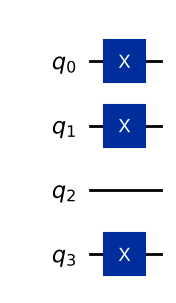

Bits 0110 -> state probabilities: {'0110': 1.0}   matches: True


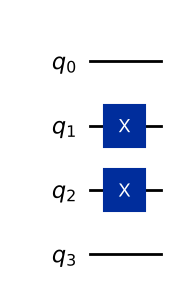

In [2]:
# Program 1: basis encoding
for bits in ["1011", "0110"]:            # given string + my own choice
    qc = basis_encode(bits)
    sv = Statevector(qc)
    probs = {str(k): float(v) for k, v in sv.probabilities_dict().items()}
    print(f"Bits {bits} -> state probabilities: {probs}   matches: {list(probs) == [bits]}")
    show(qc.draw("mpl"))

**Inference:** The bit string 1011 is stored as the basis state |1011> with probability 1 (X gates on qubits 0, 1 and 3), and my own string 0110 gives |0110>. Looping over the reversed string makes the printed state match the written string; basis encoding needs one qubit per bit.

### Program 2
Encode one feature using angle encoding: 50 marks on a scale of 0 to 100. Display the statevector and the probabilities. Repeat for $x$ = 0, 0.25, 0.5, 0.75 and 1 and tabulate $\theta$ and $P(1)$.

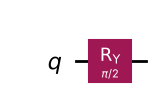

50 marks -> x = 0.5, theta = 1.5708 rad
Statevector: [0.707 0.707]   probabilities: {'0': 0.5, '1': 0.5}

  x     theta(rad)   theta(deg)   P(1)=sin^2(theta/2)
 0        0.0000        0.0       0.0000
 0.25     0.7854       45.0       0.1464
 0.5      1.5708       90.0       0.5000
 0.75     2.3562      135.0       0.8536
 1        3.1416      180.0       1.0000


In [3]:
# Program 2: angle encoding of one feature (scaling: x = (raw - min)/(max - min), theta = pi*x)
raw, lo, hi = 50, 0, 100
x = (raw - lo) / (hi - lo)
qc = angle_encode([x])
show(qc.draw("mpl"))
sv = Statevector(qc)
print(f"50 marks -> x = {x}, theta = {np.pi*x:.4f} rad")
print("Statevector:", np.round(sv.data.real, 4), "  probabilities:", {str(k): round(float(v), 4) for k, v in sv.probabilities_dict().items()})

print("\n  x     theta(rad)   theta(deg)   P(1)=sin^2(theta/2)")
for x in [0, 0.25, 0.5, 0.75, 1]:
    p1 = Statevector(angle_encode([x])).probabilities()[1]
    print(f" {x:<5}  {np.pi*x:8.4f}    {np.degrees(np.pi*x):7.1f}       {p1:.4f}")

**Inference:** 50/100 gives x = 0.5, θ = π/2 and the state 0.707|0> + 0.707|1>, i.e. P(1) = 50%. The table shows P(1) = sin²(πx/2): 0, 0.146, 0.5, 0.854, 1 — equal to x only at 0, 0.5 and 1, because the amplitudes use half the angle.

### Program 3
Encode a four-feature data sample (for example one row of the Iris dataset, scaled to 0 to 1) using angle encoding with one qubit per feature. Draw the circuit and display the probabilities.

Raw sample   : [5.1 3.5 1.4 0.2]  ( sepal length (cm), sepal width (cm), petal length (cm), petal width (cm) )
Scaled to 0-1: [0.222 0.625 0.068 0.042]


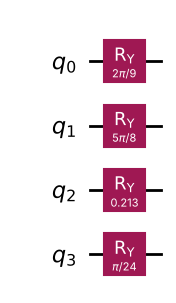

P(1) for each qubit: [0.117 0.691 0.011 0.004]
Basis-state probabilities (>0.001): {'0000': 0.2683, '0001': 0.0355, '0010': 0.601, '0011': 0.0796, '0100': 0.0031, '0110': 0.0069, '1000': 0.0012, '1010': 0.0026}


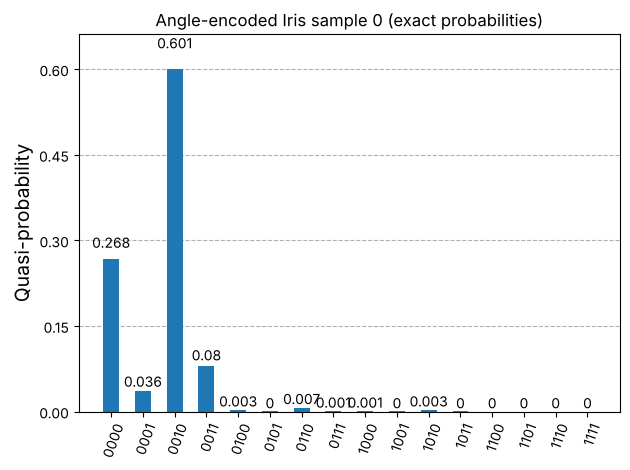

In [4]:
# Program 3: angle encoding of one Iris sample (4 features, min-max scaled over the dataset)
iris = load_iris()
X_all = MinMaxScaler().fit_transform(iris.data)
x = X_all[0]
print("Raw sample   :", iris.data[0], " (", ", ".join(iris.feature_names), ")")
print("Scaled to 0-1:", np.round(x, 3))
qc = angle_encode(x)
show(qc.draw("mpl"))
sv = Statevector(qc)
print("P(1) for each qubit:", np.round([np.sin(np.pi * xi / 2) ** 2 for xi in x], 3))
probs = {k: v for k, v in sv.probabilities_dict().items() if v > 1e-3}
print("Basis-state probabilities (>0.001):", {str(k): round(float(v), 4) for k, v in probs.items()})
show(plot_histogram(sv.probabilities_dict(), title="Angle-encoded Iris sample 0 (exact probabilities)"))

**Inference:** The four scaled features (0.222, 0.625, 0.068, 0.042) become rotations on four qubits. The joint distribution is a product of the single-qubit distributions; the most likely outcome is 0010 because only feature 1 (sepal width, qubit 1) has P(1) > 0.5.

### Program 4
Encode the vectors (3, 4) and (1, 2, 3, 4) using amplitude encoding with qc.initialize. Verify that the probabilities are the squares of the normalised values, and use qc.decompose(reps=6) to show the gates that the preparation really uses.

vector [3, 4]: normalised = [0.6 0.8]
   probabilities = [0.36 0.64]   squares of normalised = [0.36 0.64]   match: True
   gates actually used: {'reset': 1, 'u': 1}  depth: 2


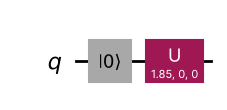

vector [1, 2, 3, 4]: normalised = [0.183 0.365 0.548 0.73 ]
   probabilities = [0.033 0.133 0.3   0.533]   squares of normalised = [0.033 0.133 0.3   0.533]   match: True
   gates actually used: {'u': 3, 'reset': 2, 'cx': 1}  depth: 4


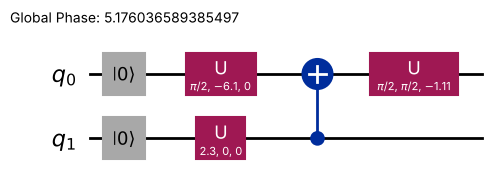

In [5]:
# Program 4: amplitude encoding with initialize
for vec in [[3, 4], [1, 2, 3, 4]]:
    v = np.array(vec, dtype=float)
    vn = v / np.linalg.norm(v)
    n = int(np.log2(len(v)))
    qc = QuantumCircuit(n)
    qc.initialize(vn, range(n))
    sv = Statevector(qc)
    print(f"vector {vec}: normalised = {np.round(vn, 4)}")
    print("   probabilities =", np.round(sv.probabilities(), 4), "  squares of normalised =", np.round(vn**2, 4),
          "  match:", np.allclose(sv.probabilities(), vn**2))
    dec = qc.decompose(reps=6)
    print("   gates actually used:", dict(dec.count_ops()), " depth:", dec.depth())
    show(dec.draw("mpl"))

**Inference:** (3,4) → 0.6|0> + 0.8|1> (P = 0.36, 0.64) and (1,2,3,4) → (1,2,3,4)/√30 on 2 qubits (P = 1/30, 4/30, 9/30, 16/30): probabilities equal the squared normalised values. Decomposing initialize shows the real gates: one rotation for (3,4), but already 3 rotations + 1 CNOT (plus resets) for 4 values; the gate count grows roughly linearly with the vector length, so state preparation is the costly part of amplitude encoding.

### Program 5
For a four-feature vector, compare basis, angle and amplitude encoding in a table: number of qubits, number of gates and circuit depth.

In [6]:
# Program 5: compare the three encodings for one four-feature vector (Iris sample 0, scaled)
x = X_all[0]
bits = "".join("1" if xi >= 0.5 else "0" for xi in x[::-1])     # basis: 1 bit per feature (threshold 0.5)
circs = {
    "Basis (1 bit/feature)": basis_encode(bits),
    "Angle (Ry)":            angle_encode(x),
}
amp = QuantumCircuit(2); amp.initialize(x / np.linalg.norm(x), [0, 1])
circs["Amplitude"] = amp
basis = ["u", "cx"]
print(f"{'Encoding':<22}{'qubits':>7}{'gates':>8}{'depth':>7}   (after transpiling to u, cx)")
for name, qc in circs.items():
    t = transpile(qc, basis_gates=basis, optimization_level=0)
    print(f"{name:<22}{qc.num_qubits:>7}{t.size():>8}{t.depth():>7}   {dict(t.count_ops())}")

Encoding               qubits   gates  depth   (after transpiling to u, cx)
Basis (1 bit/feature)       4       1      1   {'u': 1}
Angle (Ry)                  4       4      1   {'u': 4}
Amplitude                   2       6      4   {'u': 3, 'reset': 2, 'cx': 1}


**Inference:** For n = 4 features basis and angle encoding use 4 qubits with depth 1, while amplitude encoding uses only log₂4 = 2 qubits but needs more gates and depth (including CNOTs). Amplitude encoding saves qubits at the cost of a deeper circuit; basis encoding also loses information unless more bits per feature are used.

### Program 6
For two data points with two features each, compute the quantum kernel value $k(x,x\prime)$ as the squared overlap of their angle-encoded states. Verify that $k(x,x) = 1$.

In [7]:
# Program 6: quantum kernel for two 2-feature points (already scaled to [0,1])
x1 = np.array([0.2, 0.7])
x2 = np.array([0.5, 0.3])
k12 = kernel(x1, x2)
analytic = np.prod(np.cos(np.pi * (x1 - x2) / 2) ** 2)
print("k(x1, x2) =", round(k12, 6), "  analytic prod cos^2(pi*(x1-x2)/2) =", round(analytic, 6))
print("k(x1, x1) =", round(kernel(x1, x1), 6))
print("k(x2, x2) =", round(kernel(x2, x2), 6))

k(x1, x2) = 0.519609   analytic prod cos^2(pi*(x1-x2)/2) = 0.519609
k(x1, x1) = 1.0
k(x2, x2) = 1.0


**Inference:** k(x, x′) ≈ 0.520 for x = (0.2, 0.7) and x′ = (0.5, 0.3), matching the closed form Π cos²(π(xᵢ−x′ᵢ)/2) for this product feature map, and k(x, x) = 1 for both points, as required for identical states.

### Program 7
Compute the quantum kernel matrix for a small dataset (for example 20 samples from the first two classes of the Iris dataset, using two features). Display the matrix as a heat map and comment on its diagonal and its symmetry.

Diagonal all 1: True    symmetric: True
Mean kernel within class 0: 0.890, within class 1: 0.702, between classes: 0.418


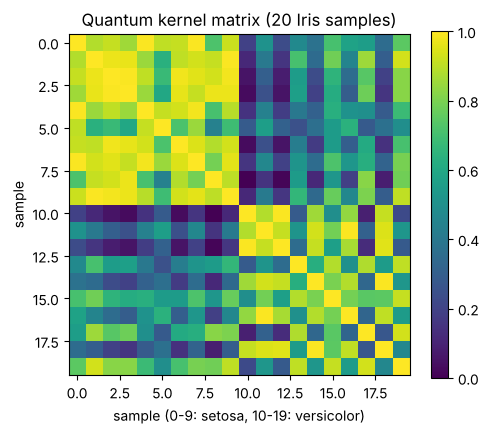

In [8]:
# Program 7: 20x20 quantum kernel matrix (Iris classes 0 and 1, features: sepal length & sepal width)
mask = iris.target < 2
X2 = MinMaxScaler().fit_transform(iris.data[mask][:, :2])
y2 = iris.target[mask]
idx = np.r_[0:10, 50:60]                 # 10 samples of each class
K = kernel_matrix(X2[idx], X2[idx])
print("Diagonal all 1:", np.allclose(np.diag(K), 1), "   symmetric:", np.allclose(K, K.T))
print("Mean kernel within class 0: %.3f, within class 1: %.3f, between classes: %.3f" % (
    K[:10, :10].mean(), K[10:, 10:].mean(), K[:10, 10:].mean()))
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(K, cmap="viridis", vmin=0, vmax=1)
ax.set_title("Quantum kernel matrix (20 Iris samples)")
ax.set_xlabel("sample (0-9: setosa, 10-19: versicolor)"); ax.set_ylabel("sample")
fig.colorbar(im); show(fig)

**Inference:** The diagonal is exactly 1 (every state overlaps perfectly with itself) and the matrix is symmetric because |<a|b>|² = |<b|a>|². The two 10×10 diagonal blocks are brighter than the off-diagonal blocks: samples from the same class are more similar than samples from different classes, which is what makes the kernel useful.

### Program 8
QSVM: train SVC(kernel=\"precomputed\") with the quantum kernel matrix on a training split of the dataset and report the accuracy on the test split. Compare with a classical SVM using the RBF kernel on the same split.

In [9]:
# Program 8: QSVM with the precomputed quantum kernel vs classical RBF SVM
Xtr, Xte, ytr, yte = train_test_split(X2, y2, test_size=0.3, random_state=42, stratify=y2)
K_train = kernel_matrix(Xtr, Xtr)
K_test = kernel_matrix(Xte, Xtr)
qsvm = SVC(kernel="precomputed").fit(K_train, ytr)
acc_q = accuracy_score(yte, qsvm.predict(K_test))
rbf = SVC(kernel="rbf").fit(Xtr, ytr)
acc_c = accuracy_score(yte, rbf.predict(Xte))
print(f"Train / test sizes: {len(Xtr)} / {len(Xte)}")
print(f"QSVM (quantum kernel) test accuracy : {acc_q:.3f}")
print(f"Classical SVM (RBF)   test accuracy : {acc_c:.3f}")
print("Support vectors (quantum):", qsvm.n_support_, "  (RBF):", rbf.n_support_)

Train / test sizes: 70 / 30
QSVM (quantum kernel) test accuracy : 1.000
Classical SVM (RBF)   test accuracy : 1.000
Support vectors (quantum): [10  8]   (RBF): [7 8]


**Inference:** Both the QSVM with the precomputed quantum kernel and the classical RBF SVM reach 100% test accuracy on the 30 test samples (70 training samples, 2 features). Setosa and versicolor are almost linearly separable, so the quantum kernel works but gives no advantage here; it simply matches the classical method.

### Program 9
Build the swap test circuit for two angle-encoded two-feature data points. Estimate the fidelity from $P(0)$ with at least 8192 shots and compare it with the exact kernel value from Program 6.

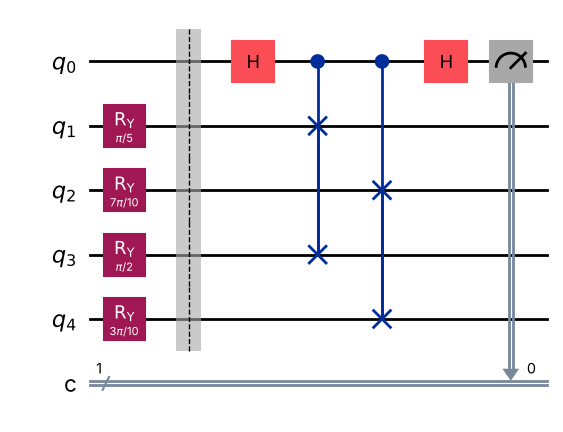

Counts: {'1': 1947, '0': 6245}
P(0) = 0.7623  ->  fidelity estimate = 2*P(0) - 1 = 0.5247
Exact kernel from Program 6 = 0.5196


In [10]:
# Program 9: swap test for the two points of Program 6, 8192 shots
a, b = angle_encode(x1), angle_encode(x2)
qc = QuantumCircuit(5, 1)                  # q0 = ancilla, q1-q2 = |a>, q3-q4 = |b>
qc.compose(a, [1, 2], inplace=True)
qc.compose(b, [3, 4], inplace=True)
qc.barrier()
qc.h(0)
qc.cswap(0, 1, 3); qc.cswap(0, 2, 4)
qc.h(0)
qc.measure(0, 0)
show(qc.draw("mpl"))
counts = run(qc, shots=8192)
p0 = counts.get("0", 0) / 8192
print("Counts:", counts)
print(f"P(0) = {p0:.4f}  ->  fidelity estimate = 2*P(0) - 1 = {2*p0-1:.4f}")
print(f"Exact kernel from Program 6 = {k12:.4f}")

**Inference:** P(0) ≈ 0.762, giving a fidelity estimate 2P(0) − 1 ≈ 0.525, close to the exact value 0.520 from Program 6; the small difference is shot noise (standard error ≈ 0.01). The swap test is how the kernel would be estimated on hardware, where statevectors are not available.

### Program 10
Quantum clustering: generate a two-cluster dataset of 20 points (for example with make_blobs), compute its quantum kernel matrix and cluster the points into two groups using the kernel matrix. Compare the labels with classical k-means and plot both results.

Quantum-kernel clustering labels: [0 1 1 0 1 0 1 1 1 0 0 1 0 0 1 0 0 1 1 0]
Classical k-means labels        : [0 1 1 0 1 0 1 1 1 0 0 1 0 0 1 0 0 1 1 0]
Agreement between the two (ARI) : 1.0
ARI vs true blobs  quantum: 1.000   k-means: 1.000


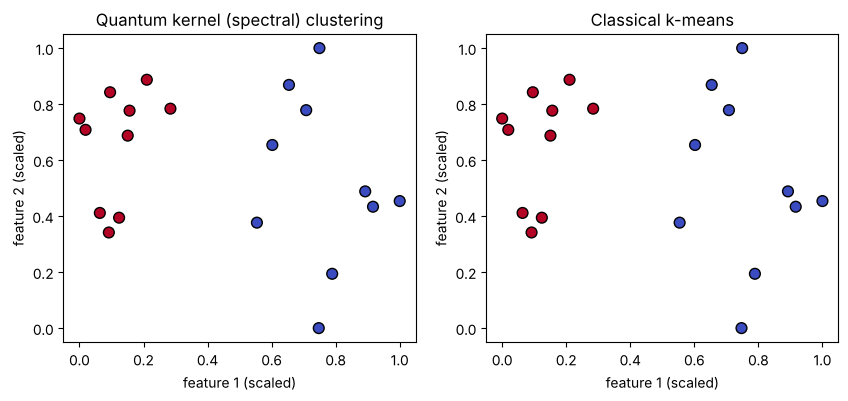

In [11]:
# Program 10: quantum clustering of 20 blob points vs classical k-means
Xb, yb = make_blobs(n_samples=20, centers=2, cluster_std=1.2, random_state=7)
Xb_s = MinMaxScaler().fit_transform(Xb)
Kb = kernel_matrix(Xb_s, Xb_s)
q_labels = SpectralClustering(n_clusters=2, affinity="precomputed", random_state=0).fit_predict(Kb)
k_labels = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(Xb_s)
print("Quantum-kernel clustering labels:", q_labels)
print("Classical k-means labels        :", k_labels)
print("Agreement between the two (ARI) :", round(adjusted_rand_score(q_labels, k_labels), 3))
print("ARI vs true blobs  quantum: %.3f   k-means: %.3f" % (adjusted_rand_score(yb, q_labels), adjusted_rand_score(yb, k_labels)))
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
for ax, lab, t in zip(axs, [q_labels, k_labels], ["Quantum kernel (spectral) clustering", "Classical k-means"]):
    ax.scatter(Xb_s[:, 0], Xb_s[:, 1], c=lab, cmap="coolwarm", s=60, edgecolors="k")
    ax.set_title(t); ax.set_xlabel("feature 1 (scaled)"); ax.set_ylabel("feature 2 (scaled)")
show(fig)

**Inference:** Spectral clustering on the quantum kernel matrix and classical k-means give identical groupings (ARI = 1.0 between them and with the true blob labels). The fidelity kernel captures the distance structure of well-separated clusters, but on this easy dataset it offers no advantage over k-means.

## Viva Q&A

**1. What is data encoding (a feature map), and why is it needed?**  
Data encoding (a feature map) is the step that loads classical numbers into a quantum state |φ(x)> by applying gates whose type or angle depends on the data. It is needed because a quantum circuit can only process quantum states, not classical numbers directly.

**2. How many qubits do basis, angle and amplitude encoding need for n features?**  
Basis encoding: one qubit per bit (n qubits for n binary features, more if each feature needs several bits). Angle encoding: n qubits (one per feature). Amplitude encoding: ⌈log₂ n⌉ qubits.

**3. In angle encoding, why is the angle taken as $\pi x$ and not $2\pi x$?**  
With x scaled to [0,1], θ = πx spans 0 to π, which maps x = 0 to |0> and x = 1 to |1> uniquely. With 2πx, θ = 2π would bring the state back to −|0>, so x = 0 and x = 1 would give the same probabilities and distinct values would overlap.

**4. In angle encoding, why is the probability of measuring 1 not equal to the data value?**  
Ry(θ)|0> = cos(θ/2)|0> + sin(θ/2)|1>, so P(1) = sin²(πx/2), a nonlinear function of x. It equals x only at x = 0, 0.5 and 1 (e.g. x = 0.25 gives P(1) = 0.146).

**5. Why is amplitude encoding costly even though it uses few qubits?**  
Although it needs only log₂N qubits, preparing an arbitrary state with N amplitudes needs a circuit of O(N) gates (many rotations and CNOTs), so the loading step can cancel any speed-up of the algorithm that follows.

**6. What is a quantum kernel?**  
A quantum kernel is a similarity measure between two data points computed from their encoded quantum states: k(x, x′) = |<φ(x)|φ(x′)>|², the fidelity of the two states.

**7. Why is every diagonal entry of the kernel matrix equal to 1?**  
Because the diagonal entry is k(x, x) = |<φ(x)|φ(x)>|² = 1 for any normalised state — a point is perfectly similar to itself.

**8. In QSVM, which part runs on the quantum computer and which part is classical?**  
The quantum computer only evaluates the kernel entries (encoding the states and estimating the overlaps, e.g. with the swap test). Training the SVM (finding support vectors and weights) and making predictions are done classically, e.g. with SVC(kernel='precomputed').

**9. What does the swap test measure?**  
The swap test measures the overlap of two states: the ancilla measures 0 with probability P(0) = ½ + ½|<a|b>|², so |<a|b>|² = 2P(0) − 1. It equals 1 for identical states and 0 for orthogonal ones.

**10. Does a quantum kernel guarantee better accuracy than a classical kernel?**  
No. A quantum kernel is just another kernel; its accuracy depends on whether the feature map suits the data. On small, simple datasets (like here) a classical RBF kernel performs as well or better, and any advantage must be shown honestly by comparison.

## Result

Classical data was encoded into quantum states using basis, angle and amplitude encoding in Qiskit, and the three encodings were compared in qubits, gates and depth. A quantum kernel was computed from the squared overlap of angle-encoded states (k(x,x) = 1, symmetric kernel matrix), verified with the swap test, used in a QSVM on the Iris dataset and for clustering a two-blob dataset, and compared with a classical RBF SVM and k-means. Hence the experiment was successfully completed.